# Tests where n_features > 1

In [2]:
from himalaya.ridge import BandedRidgeCV
import numpy as np
import torch

import matplotlib.pyplot as plt

In [7]:
np.random.seed(42)
T = 500
N = 8

X_1 = np.expand_dims(np.linspace(-1, 1, T), axis=1) + np.random.randn(T, N) * 0.1
X_2 = np.expand_dims(np.linspace(1, -1, T), axis=1) + np.random.randn(T, N) * 0.1
Y = np.expand_dims(np.linspace(-1, 1, T), axis=1) + np.random.randn(T, N) * 0.1

In [5]:
print(X_1)
print(X_1.shape)

[[-0.95032858 -1.01382643 -0.93523115 ... -1.0234137  -0.84207872
  -0.92325653]
 [-1.04293942 -0.94173598 -1.04233375 ... -1.18732001 -1.16848377
  -1.05222074]
 [-1.09326708 -0.96055923 -1.08278638 ... -1.0145616  -0.98523115
  -1.13445879]
 ...
 [ 1.04260807  1.13671454  1.04879429 ...  1.15604542  1.30718964
   0.87963456]
 [ 1.02028019  0.78778211  1.0513069  ...  0.91853049  0.82707368
   0.94886561]
 [ 0.80245122  1.07510995  0.7934917  ...  0.96797022  1.16433782
   1.03606479]]
(500, 8)


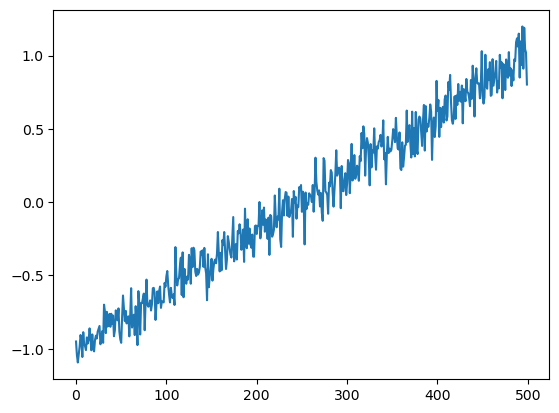

In [6]:
plt.plot(X_1[:, 0])

## Fit model

In [18]:
X = [X_1, X_2]
solver_params = {"alphas": np.logspace(-1, 1, 6, base=2)}

model = BandedRidgeCV(groups="input", cv=50, solver_params=solver_params)
model.fit(X, Y)

[........................................] 100% | 3.41 sec | 100 random sampling with cv | 
💡 Hello world from himalaya/ridge/_sklearn_api.py !


GroupRidgeCV(cv=50, groups='input',
             solver_params={'alphas': array([0.5       , 0.65975396, 0.87055056, 1.14869835, 1.51571657,
       2.        ])})

In [19]:
best_alphas_ret_ = model.best_alphas_ret_
best_alphas_ = model.best_alphas_
best_gammas_ = model.best_gammas_

In [17]:
print(best_alphas_)
print(best_alphas_ret_)
print(best_gammas_)

[2. 2. 2. 2. 2. 2. 2. 2.]
[2. 2. 2. 2. 2. 2. 2. 2.]
[[0.31593754 0.44513848 0.71192941 0.24834613 0.61711719 0.48200164
  0.56933465 0.35446056]
 [0.68406246 0.55486152 0.28807059 0.75165387 0.38288281 0.51799836
  0.43066535 0.64553944]]


In [20]:
print(best_gammas_)

[[0.30419062 0.43438984 0.72004766 0.24886869 0.62151959 0.48470839
  0.58659536 0.37770346]
 [0.69580938 0.56561016 0.27995234 0.75113131 0.37848041 0.51529161
  0.41340464 0.62229654]]
